Setup

In [1]:
%pip install numpy
%pip install matplotlib
%pip install tensorboard
import numpy as np
import matplotlib.pyplot as plt
from juliacall import Main as jl
from juliacall import Pkg as jlPkg
jlPkg.activate("../.")
jl.Pkg.instantiate()
jl.include("../models/rl_repressilator_past_amort_setup.jl")
#jlPkg.instantiate() #run the first time using this repo

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `c:\Users\micha\GeneCircuitsRL`


observation (generic function with 2 methods)

Second peak value: 0.7038096038235359


In [2]:
fixed_point = -np.array([1,-1,0,0])

In [3]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch as th
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class Custom1DCNNExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=128, obs_dim=128, action_dim=3, n_steps=5):
        super(Custom1DCNNExtractor, self).__init__(observation_space, features_dim)

        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.n_steps = n_steps

        n_input_channels = 1
        seq_len = obs_dim

        # CNN to process each observation chunk
        self.cnn = nn.Sequential(
            nn.Conv1d(n_input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

        # Determine CNN output size
        with th.no_grad():
            sample_obs = th.zeros((1, n_input_channels, seq_len), dtype=th.float32)
            cnn_output_dim = self.cnn(sample_obs).shape[1]

        # Concatenate obs features and raw actions across all steps
        combined_dim = self.n_steps * cnn_output_dim + self.n_steps * action_dim

        self.linear = nn.Sequential(
            nn.Linear(combined_dim, features_dim),
            nn.ReLU()
        )

    def forward(self, observations):
        """
        observations: (batch, 1, obs1 + act1 + ... + obsN + actN)
        """
        obs_feats = []
        act_feats = []

        for i in range(self.n_steps):
            obs_start = i * (self.obs_dim + self.action_dim)
            act_start = obs_start + self.obs_dim
            act_end = act_start + self.action_dim

            obs = observations[:, :, obs_start:act_start]  # (batch, 1, obs_dim)
            act = observations[:, 0, act_start:act_end]    # (batch, action_dim)

            obs_feat = self.cnn(obs)                       # (batch, cnn_output_dim)
            obs_feats.append(obs_feat)
            act_feats.append(act)

        combined = th.cat(obs_feats + act_feats, dim=1)
        return self.linear(combined)


# ======================
#  Environment
# ======================

import random
import torch
from gymnasium.utils import seeding

class CustomEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, max_episode_steps=5):
        super(CustomEnv, self).__init__()

        self.obs_dim = 128
        self.action_dim = 3          # design params: kX, km, K
        self.uncertain_dim = 4       # H, γX, γm, ϵ
        self.n_steps = max_episode_steps

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(1, self.n_steps * (self.obs_dim + self.action_dim)),
            dtype=np.float32
        )

        self.action_space = spaces.Box(
            low=-1,
            high=1,
            shape=(self.action_dim,),
            dtype=np.float32
        )

        self.max_episode_steps = max_episode_steps
        self.current_step = 0
        self.uncertain = fixed_point

        self.effective_observation = np.zeros(self.observation_space.shape, dtype=np.float32)
    
    def seed(self, seed=None):
        self._np_random, seed = seeding.np_random(seed)
        np.random.seed(seed)
        random.seed(seed)
        torch.manual_seed(seed)
        jl.seval(f"Random.seed!({seed})")  # sync seed with Julia
        return [seed]
    
    def reset(self, seed=None, options=None):
        self.uncertain = fixed_point
        
        self.current_step = 0
        self.effective_observation[:] = 0.0

        info = {}
        return self.effective_observation.copy(), info

    def step(self, action):
        params_action = np.concatenate((self.uncertain, action))
        reward = jl.reward_normalized_past_amort(params_action, 1 / 7)
        rew = np.clip(reward, -5, 5)

        obs_vector = jl.observation(self.uncertain, action)
        obs_vector = np.array(obs_vector).reshape(1, -1).astype(np.float32)

        if self.current_step < self.max_episode_steps:
            obs_start = self.current_step * (self.obs_dim + self.action_dim)
            act_start = obs_start + self.obs_dim

            self.effective_observation[:, obs_start:act_start] = obs_vector
            self.effective_observation[:, act_start:act_start + self.action_dim] = action

        self.current_step += 1
        terminated = self.current_step >= self.max_episode_steps
        truncated = False
        info = {}

        return self.effective_observation.copy(), rew, terminated, truncated, info


In [4]:
from stable_baselines3.common.env_checker import check_env
env = CustomEnv()
check_env(env)

c:\Users\micha\miniconda3\envs\circuitsrl\Lib\site-packages\stable_baselines3\common\env_checker.py:316: UserWarning: Your observation  has an unconventional shape (neither an image, nor a 1D vector). We recommend you to flatten the observation to have only a 1D vector or use a custom policy to properly process the data.
  warnings.warn(


Training

In [5]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

log_dir = "../logs/rl_repressilator_past_amort_multi_step_frame_5_fixed_2/"
os.makedirs(log_dir, exist_ok=True)


SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
jl.seval(f"Random.seed!({SEED})") 
env = CustomEnv()
env.seed(SEED)
env.reset(seed=SEED)
env = Monitor(env, filename=log_dir)

policy_kwargs = dict(
    features_extractor_class=Custom1DCNNExtractor,
    features_extractor_kwargs=dict(features_dim=128),
)

model = PPO(
    "CnnPolicy", 
    env,
    policy_kwargs=policy_kwargs,
    verbose=1,
    tensorboard_log=log_dir,
    seed=SEED
)



Using cpu device
Wrapping the env in a DummyVecEnv.


In [6]:
model.learn(total_timesteps=1500000)

obs, info = env.reset()
action, _ = model.predict(obs)
print("Test action:", action)

Logging to ../logs/rl_repressilator_past_amort_multi_step_frame_5_fixed_2/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5        |
|    ep_rew_mean     | 0.387    |
| time/              |          |
|    fps             | 22       |
|    iterations      | 1        |
|    time_elapsed    | 91       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 5           |
|    ep_rew_mean          | 0.926       |
| time/                   |             |
|    fps                  | 17          |
|    iterations           | 2           |
|    time_elapsed         | 234         |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.017464137 |
|    clip_fraction        | 0.216       |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.21 

In [7]:
model.save(os.path.join(log_dir, "ppo_model"))

Evaluation

In [15]:
log_dir = "../logs/rl_repressilator_past_amort_multi_step_frame_5_fixed_2/"

In [16]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# test environment
env = CustomEnv()

# ==== Configuration ====
model_path = os.path.join(log_dir, "ppo_model")
monitor_file = os.path.join(log_dir, "monitor.csv")

df = pd.read_csv(monitor_file, skiprows=1)  # Skip header comment row

In [17]:
model = PPO.load(model_path)


C:\Users\micha\AppData\Local\Temp\ipykernel_25424\2659683471.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


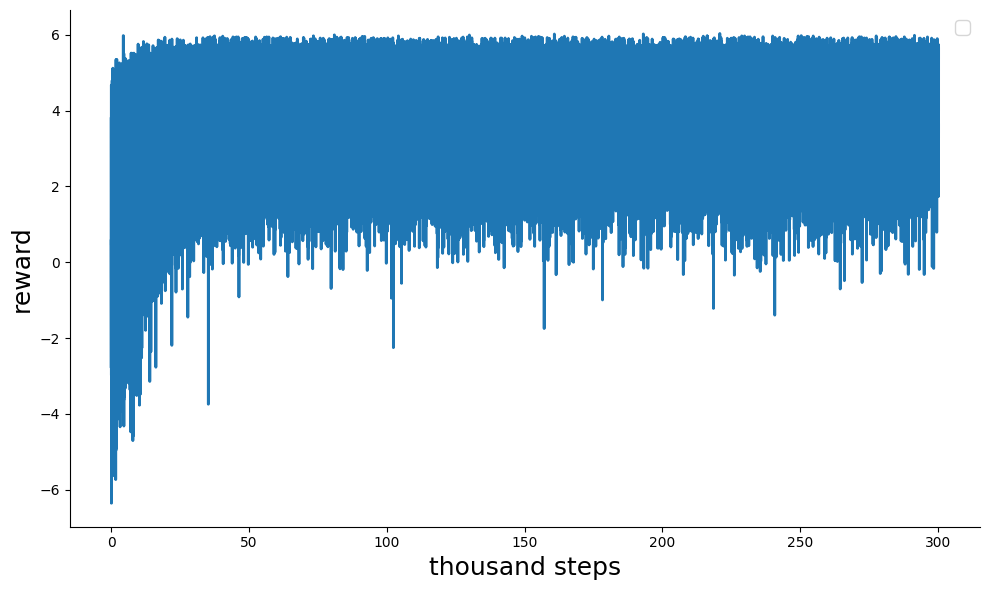

In [18]:
# ==== 3. Plot learning curve ====
plt.figure(figsize=(10, 6))
sns.lineplot(x=[x / 1e3 for x in range(len(df))], y=df["r"], linewidth=2)

plt.xlabel("thousand steps", fontsize=18)
plt.ylabel("reward", fontsize=18)
plt.legend(fontsize=14)
sns.despine()

plt.tight_layout()
# plt.savefig("learning_curve_3.pdf", format="pdf")
plt.show()

C:\Users\micha\AppData\Local\Temp\ipykernel_25424\4038937236.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Action taken: [-1.          0.7724438  -0.48736322]
False
First reward: 0.9656183659427906
(1, 655)
Action taken: [-0.6027305  1.         1.       ]
Second reward: 0.4269675582271665
Action taken: [-0.59762865  0.94952106  1.        ]
Third reward: 1.1515526647448941
False


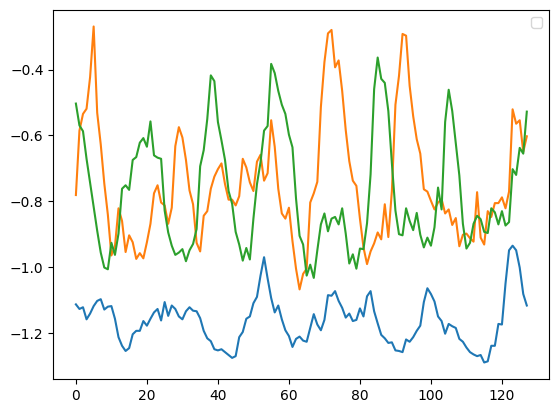

In [19]:
obs, info = env.reset()  # Reset the environment with a specific frequency

action, _states = model.predict(obs, deterministic=True)
action
print("Action taken:", action)
first_params = np.hstack((env.uncertain, action))



# print("First Reward:",jl.reward_normalized_past_amort(first_params, 1/7))
obs, reward, terminated, truncated, info = env.step(action)
print(terminated)

print("First reward:", reward)
print(obs.shape)

# plt.plot(jl.observation_normalized(np.concatenate((env.uncertain, action))), label="Second Design")
plt.legend()
# Take action in the environment

action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Second reward:", reward)

plt.plot(obs[0,0:128], label="First Design")
plt.plot(obs[0,132:260], label="Second Design")

action, _states = model.predict(obs, deterministic=True)

plt.plot(jl.observation(env.uncertain, action), label="Third Design")

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Third reward:", reward)


print(terminated)




In [ ]:
first_rewards = np.zeros(1000)
second_rewards = np.zeros(1000)
third_rewards = np.zeros(1000)
forth_rewards = np.zeros(1000)
fifth_rewards = np.zeros(1000)

env.seed(31415)

for i in range(1000):
    obs, info = env.reset() 
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    first_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    second_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    third_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    forth_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    fifth_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5



Text(0, 0.5, 'Reward')

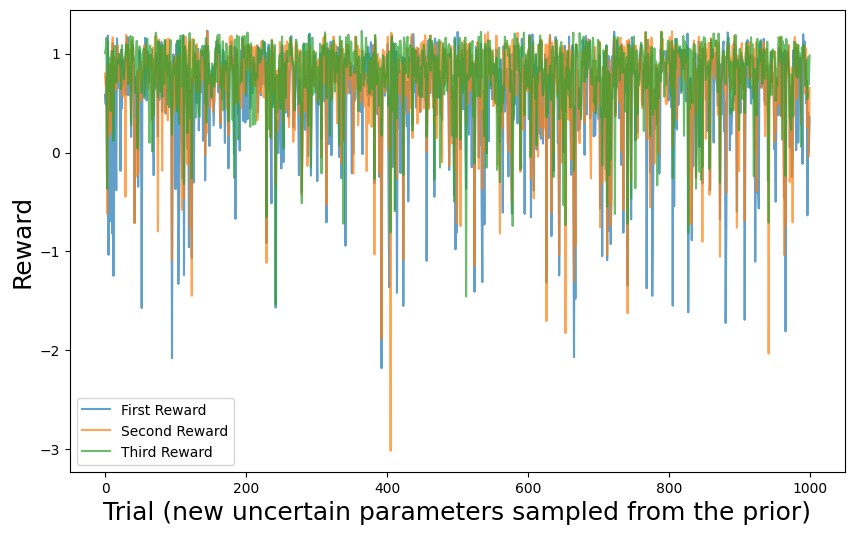

In [9]:

plt.figure(figsize=(10, 6))
plt.plot(first_rewards, label='First Reward', alpha=0.7)
plt.plot(second_rewards, label='Second Reward', alpha=0.7)
plt.plot(third_rewards, label='Third Reward', alpha=0.7)
plt.legend()
plt.xlabel("Trial (new uncertain parameters sampled from the prior)", fontsize=18)
plt.ylabel("Reward", fontsize=18)


Text(0, 0.5, 'Reward')

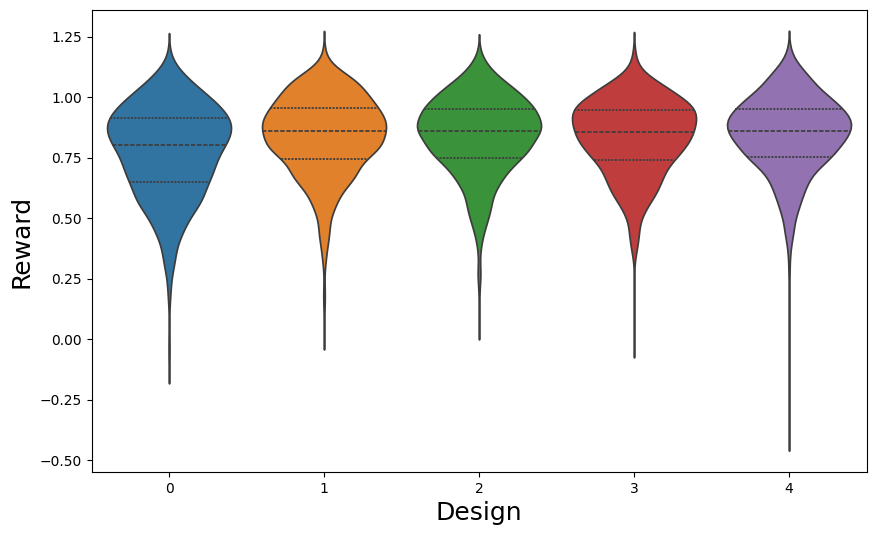

In [12]:
#plot violins seaborn
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.violinplot(data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards], inner="quartile")
plt.xlabel("Design", fontsize=18)
plt.ylabel("Reward", fontsize=18)


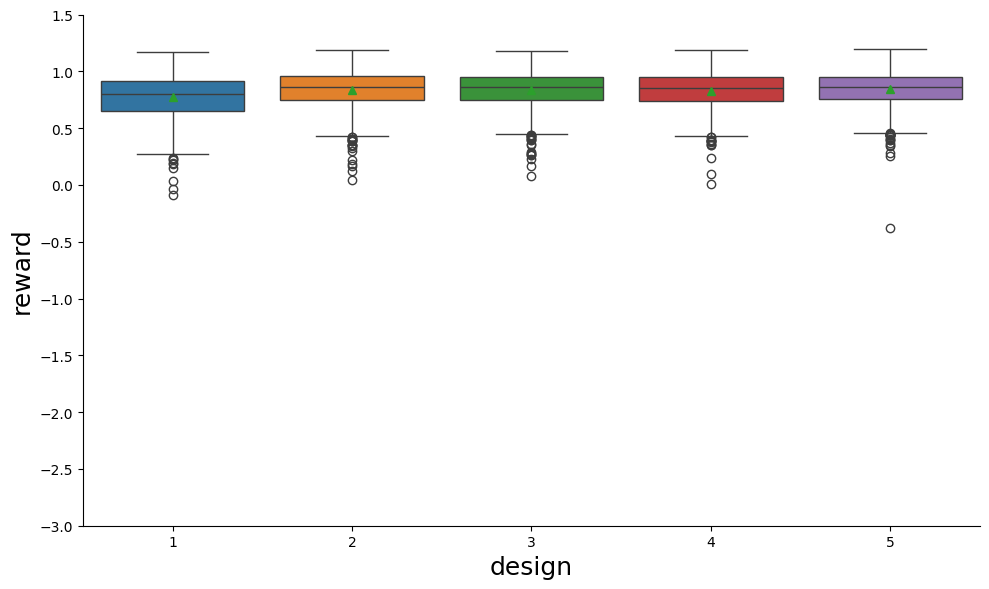

In [ ]:
# Plot boxplot with seaborn
plt.figure(figsize=(3, 3))
sns.boxplot(data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards], showmeans=True, showfliers = False)

# Set x-axis labels starting from 1
plt.xticks(ticks=range(5), labels=["1", "2", "3", "4", "5"])

plt.xlabel("Step", fontsize=12)
plt.ylabel("Reward", fontsize=12)

sns.despine()
plt.tight_layout()
# plt.savefig("boxes_std.pdf", format="pdf")
plt.show()

In [ ]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# test environment
env = CustomEnv()

# ==== Configuration ====
log_dir = "../logs/rl_repressilator_past_amort_multi_step_frame_5_1234"
model_path = os.path.join(log_dir, "ppo_model")

model = PPO.load(model_path)

first_rewards_adapt = np.zeros(1000)
second_rewards_adapt = np.zeros(1000)
third_rewards_adapt = np.zeros(1000)
forth_rewards_adapt = np.zeros(1000)
fifth_rewards_adapt = np.zeros(1000)

env.seed(31415)

for i in range(1000):
    obs, info = env.reset() 
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    first_rewards_adapt[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    second_rewards_adapt[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    third_rewards_adapt[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    forth_rewards_adapt[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    fifth_rewards_adapt[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5

# Plot boxplot with seaborn
plt.figure(figsize=(3, 3))
sns.boxplot(data=[first_rewards_adapt, second_rewards_adapt, third_rewards_adapt, forth_rewards_adapt, fifth_rewards_adapt], showmeans=True, showfliers = False)

# Set x-axis labels starting from 1
plt.xticks(ticks=range(5), labels=["1", "2", "3", "4", "5"])

plt.xlabel("Step", fontsize=12)
plt.ylabel("Reward", fontsize=12)

sns.despine()
plt.tight_layout()
# plt.savefig("boxes_std.pdf", format="pdf")
plt.show()
